In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import glob
import os

In [3]:
df = pd.read_csv("../anac_data/Results/gc_photometry_cross_calibrated_v18.csv")
print("Numbers of sources", len(df))
df.columns.tolist()

Numbers of sources 3799


['recno',
 'T17ID',
 'oldID',
 'RAJ2000',
 'DEJ2000',
 'Prob',
 'Rgc',
 'PA',
 'umag',
 'gmag',
 'rmag',
 'imag',
 'zmag',
 'e_umag',
 's_umag',
 'e_gmag',
 's_gmag',
 'e_rmag',
 's_rmag',
 'e_imag',
 's_imag',
 'e_zmag',
 's_zmag',
 'FLUX_F378_2',
 'FLUXERR_F378_2',
 'MAG_F378_2',
 'MAGERR_F378_2',
 'SNR_F378_2',
 'AP_CORR_F378_2',
 'FLUX_F378_3',
 'FLUXERR_F378_3',
 'MAG_F378_3',
 'MAGERR_F378_3',
 'SNR_F378_3',
 'AP_CORR_F378_3',
 'FLUX_F395_2',
 'FLUXERR_F395_2',
 'MAG_F395_2',
 'MAGERR_F395_2',
 'SNR_F395_2',
 'AP_CORR_F395_2',
 'FLUX_F395_3',
 'FLUXERR_F395_3',
 'MAG_F395_3',
 'MAGERR_F395_3',
 'SNR_F395_3',
 'AP_CORR_F395_3',
 'FLUX_F410_2',
 'FLUXERR_F410_2',
 'MAG_F410_2',
 'MAGERR_F410_2',
 'SNR_F410_2',
 'AP_CORR_F410_2',
 'FLUX_F410_3',
 'FLUXERR_F410_3',
 'MAG_F410_3',
 'MAGERR_F410_3',
 'SNR_F410_3',
 'AP_CORR_F410_3',
 'FLUX_F430_2',
 'FLUXERR_F430_2',
 'MAG_F430_2',
 'MAGERR_F430_2',
 'SNR_F430_2',
 'AP_CORR_F430_2',
 'FLUX_F430_3',
 'FLUXERR_F430_3',
 'MAG_F430_3',
 'M

In [4]:
def analyze_default_errors(df):
    """Analiza en profundidad los errores con valor 0.543"""
    
    filters = ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']
    
    print("=== ANÁLISIS DETALLADO DE ERRORES 0.543 ===")
    
    for filter in filters:
        err_col = f'MAGERR_{filter}_3'
        mag_col = f'MAG_{filter}_3'
        snr_col = f'SNR_{filter}_3'
        flux_col = f'FLUX_{filter}_3'
        
        if err_col in df.columns:
            # Estadísticas básicas
            total = len(df[err_col].dropna())
            n_0543 = (df[err_col] == 0.5428681023790647).sum()
            pct_0543 = (n_0543 / total) * 100
            
            # Características de fuentes con error 0.543
            mask_0543 = df[err_col] == 0.543
            if mask_0543.any():
                mag_0543 = df.loc[mask_0543, mag_col].median()
                snr_0543 = df.loc[mask_0543, snr_col].median()
                flux_0543 = df.loc[mask_0543, flux_col].median()
            else:
                mag_0543 = snr_0543 = flux_0543 = np.nan
            
            # Características de fuentes con error real
            mask_real = (df[err_col] != 0.543) & (df[err_col].notna())
            if mask_real.any():
                mag_real = df.loc[mask_real, mag_col].median()
                snr_real = df.loc[mask_real, snr_col].median()
                flux_real = df.loc[mask_real, flux_col].median()
            else:
                mag_real = snr_real = flux_real = np.nan
            
            print(f"\n{filter}:")
            print(f"  Total: {total}, Error=0.543: {n_0543} ({pct_0543:.1f}%)")
            print(f"  Con error 0.543 -> Mag: {mag_0543:.2f}, SNR: {snr_0543:.2f}, Flux: {flux_0543:.2e}")
            print(f"  Con error real  -> Mag: {mag_real:.2f}, SNR: {snr_real:.2f}, Flux: {flux_real:.2e}")



In [5]:
analyze_default_errors(df)

=== ANÁLISIS DETALLADO DE ERRORES 0.543 ===

F378:
  Total: 3791, Error=0.543: 1896 (50.0%)
  Con error 0.543 -> Mag: nan, SNR: nan, Flux: nan
  Con error real  -> Mag: 20.83, SNR: 2.00, Flux: 1.92e-01

F395:
  Total: 3791, Error=0.543: 2025 (53.4%)
  Con error 0.543 -> Mag: nan, SNR: nan, Flux: nan
  Con error real  -> Mag: 20.59, SNR: 2.00, Flux: 2.56e-01

F410:
  Total: 3791, Error=0.543: 1826 (48.2%)
  Con error 0.543 -> Mag: nan, SNR: nan, Flux: nan
  Con error real  -> Mag: 21.64, SNR: 2.00, Flux: 2.59e-01

F430:
  Total: 3791, Error=0.543: 1759 (46.4%)
  Con error 0.543 -> Mag: nan, SNR: nan, Flux: nan
  Con error real  -> Mag: 21.51, SNR: 2.00, Flux: 3.31e-01

F515:
  Total: 3791, Error=0.543: 1279 (33.7%)
  Con error 0.543 -> Mag: nan, SNR: nan, Flux: nan
  Con error real  -> Mag: 20.38, SNR: 2.00, Flux: 1.18e+00

F660:
  Total: 3791, Error=0.543: 274 (7.2%)
  Con error 0.543 -> Mag: nan, SNR: nan, Flux: nan
  Con error real  -> Mag: 20.06, SNR: 6.02, Flux: 1.19e+00

F861:
  T

## 2. Estrategias para Manejar Errores 0.543

In [6]:
def handle_default_errors_strategies(df):
    """Prueba diferentes estrategias para manejar errores por defecto"""
    
    strategies = {
        'conservative': 'Excluir todas las mediciones con error 0.543',
        'snr_based': 'Usar solo SNR para filtros problemáticos', 
        'magnitude_based': 'Excluir basado en magnitud límite',
        'hybrid': 'Combinación de métodos'
    }
    
    print("=== ESTRATEGIAS PARA ERRORES 0.543 ===\n")
    
    # Estrategia 1: Conservadora (excluir todo 0.543)
    conservative_counts = {}
    for filter in ['F378', 'F395', 'F410', 'F430']:
        err_col = f'MAGERR_{filter}_3'
        if err_col in df.columns:
            n_valid = len(df[df[err_col] != 0.543])
            conservative_counts[filter] = n_valid
            print(f"Estrategia 1 - {filter}: {n_valid} fuentes válidas (excluyendo 0.543)")
    
    # Estrategia 2: Basada en SNR
    print("\n--- Estrategia 2: Basada en SNR ---")
    for filter in ['F378', 'F395', 'F410', 'F430']:
        err_col = f'MAGERR_{filter}_3'
        snr_col = f'SNR_{filter}_3'
        
        if all(col in df.columns for col in [err_col, snr_col]):
            # Fuentes con error real
            real_errors = df[df[err_col] != 0.543]
            if len(real_errors) > 0:
                snr_threshold = real_errors[snr_col].quantile(0.25)  # Percentil 25 del SNR de errores reales
                n_high_snr = len(df[df[snr_col] > snr_threshold])
                print(f"{filter}: SNR threshold = {snr_threshold:.2f}, {n_high_snr} fuentes con SNR > threshold")
    
    return conservative_counts



In [7]:
conservative_results = handle_default_errors_strategies(df)

=== ESTRATEGIAS PARA ERRORES 0.543 ===

Estrategia 1 - F378: 3799 fuentes válidas (excluyendo 0.543)
Estrategia 1 - F395: 3799 fuentes válidas (excluyendo 0.543)
Estrategia 1 - F410: 3799 fuentes válidas (excluyendo 0.543)
Estrategia 1 - F430: 3799 fuentes válidas (excluyendo 0.543)

--- Estrategia 2: Basada en SNR ---
F378: SNR threshold = 0.00, 2471 fuentes con SNR > threshold
F395: SNR threshold = 0.00, 2469 fuentes con SNR > threshold
F410: SNR threshold = 0.00, 2619 fuentes con SNR > threshold
F430: SNR threshold = 0.00, 2704 fuentes con SNR > threshold


## 3. Limpieza Robusta que Considera Errores por Defecto

In [8]:
def robust_cleaning_aperture3(df, strategy='hybrid'):
    """
    Limpieza robusta que maneja explícitamente los errores por defecto 0.543
    
    Estrategias:
    - 'conservative': Excluye todos los 0.543
    - 'snr_based': Usa SNR para filtros problemáticos  
    - 'magnitude_based': Excluye fuentes muy débiles
    - 'hybrid': Combinación inteligente
    """
    
    clean_df = df.copy()
    
    # Definir umbrales basados en análisis previo
    if strategy == 'conservative':
        # Estrategia conservadora: excluir todos los 0.543 en filtros azules
        for filter in ['F378', 'F395', 'F410', 'F430']:
            err_col = f'MAGERR_{filter}_3'
            if err_col in clean_df.columns:
                clean_df = clean_df[clean_df[err_col] != 0.543]
    
    elif strategy == 'hybrid':
        # Estrategia híbrida: diferentes criterios por filtro
        hybrid_rules = {
            'F378': {'max_error': 0.5, 'min_snr': 3, 'exclude_0543': True},
            'F395': {'max_error': 0.5, 'min_snr': 3, 'exclude_0543': True},
            'F410': {'max_error': 0.6, 'min_snr': 2.5, 'exclude_0543': False},  # Más flexible
            'F430': {'max_error': 0.5, 'min_snr': 3, 'exclude_0543': True},
            'F515': {'max_error': 0.3, 'min_snr': 3, 'exclude_0543': False},
            'F660': {'max_error': 0.2, 'min_snr': 3, 'exclude_0543': False},
            'F861': {'max_error': 0.25, 'min_snr': 3, 'exclude_0543': False}
        }
        
        for filter, rules in hybrid_rules.items():
            err_col = f'MAGERR_{filter}_3'
            snr_col = f'SNR_{filter}_3'
            mag_col = f'MAG_{filter}_3'
            
            if all(col in clean_df.columns for col in [err_col, snr_col, mag_col]):
                # Construir máscara de calidad
                error_mask = clean_df[err_col] < rules['max_error']
                if rules['exclude_0543']:
                    error_mask = error_mask & (clean_df[err_col] != 0.543)
                
                quality_mask = (
                    error_mask &
                    (clean_df[snr_col] > rules['min_snr']) &
                    (clean_df[mag_col] < 90)  # Excluir valores de error
                )
                
                # Aplicar filtro
                clean_df = clean_df[quality_mask]
    
    # Contar filtros válidos después de limpieza
    valid_filters = np.zeros(len(clean_df))
    for filter in ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']:
        err_col = f'MAGERR_{filter}_3'
        if err_col in clean_df.columns:
            valid_mask = (
                (clean_df[err_col] < 1.0) &  # Error razonable
                (clean_df[err_col] != 0.543)  # Excluir por defecto
            )
            valid_filters += valid_mask.astype(int)
    
    # Filtrar por número mínimo de filtros válidos
    min_valid_filters = 4
    final_mask = valid_filters >= min_valid_filters
    clean_df = clean_df[final_mask]
    
    print(f"\n=== LIMPIEZA ROBUSTA (Estrategia: {strategy}) ===")
    print(f"Fuentes originales: {len(df)}")
    print(f"Fuentes después de limpieza: {len(clean_df)}")
    print(f"Filtros válidos por fuente: {valid_filters[final_mask].mean():.1f} en promedio")
    
    return clean_df

In [9]:
# Probar diferentes estrategias
print("🔍 PROBANDO DIFERENTES ESTRATEGIAS:\n")

strategies = ['conservative', 'hybrid']
results = {}

for strategy in strategies:
    print(f"\n--- Estrategia: {strategy.upper()} ---")
    result_df = robust_cleaning_aperture3(df, strategy=strategy)
    results[strategy] = result_df
    print(f"Fuentes finales: {len(result_df)}")

🔍 PROBANDO DIFERENTES ESTRATEGIAS:


--- Estrategia: CONSERVATIVE ---

=== LIMPIEZA ROBUSTA (Estrategia: conservative) ===
Fuentes originales: 3799
Fuentes después de limpieza: 3234
Filtros válidos por fuente: 6.1 en promedio
Fuentes finales: 3234

--- Estrategia: HYBRID ---

=== LIMPIEZA ROBUSTA (Estrategia: hybrid) ===
Fuentes originales: 3799
Fuentes después de limpieza: 104
Filtros válidos por fuente: 7.0 en promedio
Fuentes finales: 104


## 4. Análisis de Sensibilidad para Publicación

In [10]:
def sensitivity_analysis_default_errors(df):
    """Análisis de sensibilidad específico para errores 0.543"""
    
    scenarios = [
        {'name': 'Muy Conservador', 'exclude_all_0543': True, 'min_filters': 5, 'min_snr': 3.5},
        {'name': 'Moderado-Híbrido', 'exclude_all_0543': False, 'min_filters': 4, 'min_snr': 3},
        {'name': 'SNR-Focused', 'exclude_all_0543': False, 'min_filters': 4, 'min_snr': 2},  # SNR bajo para incluir más
        {'name': 'Solo-Filtros-Buenos', 'exclude_all_0543': True, 'min_filters': 3, 'min_snr': 3}  # Menos filtros requeridos
    ]
    
    print("=== ANÁLISIS DE SENSIBILIDAD - ERRORES 0.543 ===\n")
    
    sensitivity_results = []
    
    for scenario in scenarios:
        temp_df = df.copy()
        
        # Aplicar exclusión de 0.543 si es necesario
        if scenario['exclude_all_0543']:
            for filter in ['F378', 'F395', 'F410', 'F430']:
                err_col = f'MAGERR_{filter}_3'
                if err_col in temp_df.columns:
                    temp_df = temp_df[temp_df[err_col] != 0.543]
        
        # Contar filtros válidos
        valid_filters = np.zeros(len(temp_df))
        for filter in ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']:
            err_col = f'MAGERR_{filter}_3'
            snr_col = f'SNR_{filter}_3'
            
            if all(col in temp_df.columns for col in [err_col, snr_col]):
                valid_mask = (
                    (temp_df[err_col] < 0.6) &  # Error máximo
                    (temp_df[err_col] != 0.543) &  # Excluir por defecto
                    (temp_df[snr_col] > scenario['min_snr'])  # SNR mínimo
                )
                valid_filters += valid_mask.astype(int)
        
        # Aplicar filtro final
        final_mask = valid_filters >= scenario['min_filters']
        final_df = temp_df[final_mask]
        
        # Calcular estadísticas
        n_sources = len(final_df)
        retention = (n_sources / len(df)) * 100
        avg_filters = valid_filters[final_mask].mean()
        
        sensitivity_results.append({
            'Estrategia': scenario['name'],
            'Excluir 0.543': scenario['exclude_all_0543'],
            'Min Filtros': scenario['min_filters'], 
            'Min SNR': scenario['min_snr'],
            'Fuentes': n_sources,
            'Retención': f"{retention:.1f}%",
            'Filtros/Prom': f"{avg_filters:.1f}"
        })
        
        print(f"{scenario['name']}: {n_sources} fuentes ({retention:.1f}%)")
    
    return pd.DataFrame(sensitivity_results)

In [11]:
# Ejecutar análisis de sensibilidad
sensitivity_df = sensitivity_analysis_default_errors(df)
print("\n" + sensitivity_df.to_string(index=False))

=== ANÁLISIS DE SENSIBILIDAD - ERRORES 0.543 ===

Muy Conservador: 302 fuentes (7.9%)
Moderado-Híbrido: 598 fuentes (15.7%)
SNR-Focused: 1111 fuentes (29.2%)
Solo-Filtros-Buenos: 1192 fuentes (31.4%)

         Estrategia  Excluir 0.543  Min Filtros  Min SNR  Fuentes Retención Filtros/Prom
    Muy Conservador           True            5      3.5      302      7.9%          5.8
   Moderado-Híbrido          False            4      3.0      598     15.7%          5.2
        SNR-Focused          False            4      2.0     1111     29.2%          5.2
Solo-Filtros-Buenos           True            3      3.0     1192     31.4%          4.1


##  Estrategia de Limpieza Crítica

In [12]:
def critical_cleaning_aperture3(df):
    """
    Limpieza CRÍTICA que excluye todas las mediciones inválidas (error 0.543)
    y aplica criterios conservadores para paper high-impact
    """
    
    clean_df = df.copy()
    original_count = len(clean_df)
    
    print("=== LIMPIEZA CRÍTICA - EXCLUYENDO MEDICIONES INVÁLIDAS ===\n")
    
    # PASO 1: Identificar y excluir mediciones con error 0.543 (INVÁLIDAS)
    invalid_filters = {}
    for filter in ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']:
        err_col = f'MAGERR_{filter}_3'
        if err_col in clean_df.columns:
            n_invalid = (clean_df[err_col] == 0.5428681023790647).sum()
            pct_invalid = (n_invalid / len(clean_df)) * 100
            invalid_filters[filter] = n_invalid
            print(f"{filter}: {n_invalid} mediciones inválidas ({pct_invalid:.1f}%)")
    
    # PASO 2: Excluir fuentes que tienen demasiadas mediciones inválidas
    print(f"\nExcluyendo fuentes con mediciones inválidas...")
    
    # Contar mediciones válidas por fuente
    valid_measurements = np.zeros(len(clean_df))
    blue_valid = np.zeros(len(clean_df))  # Filtros azules válidos
    red_valid = np.zeros(len(clean_df))   # Filtros rojos válidos
    
    for filter in ['F378', 'F395', 'F410', 'F430']:
        err_col = f'MAGERR_{filter}_3'
        snr_col = f'SNR_{filter}_3'
        if all(col in clean_df.columns for col in [err_col, snr_col]):
            valid_mask = (
                (clean_df[err_col] != 0.543) & 
                (clean_df[err_col] < 0.5) &      # Error máximo 0.5 para azules
                (clean_df[snr_col] > 2) &        # SNR mínimo 2 para azules
                (clean_df[snr_col].notna())      # SNR no nulo
            )
            valid_measurements += valid_mask.astype(int)
            blue_valid += valid_mask.astype(int)
    
    for filter in ['F515', 'F660', 'F861']:
        err_col = f'MAGERR_{filter}_3'
        snr_col = f'SNR_{filter}_3'
        if all(col in clean_df.columns for col in [err_col, snr_col]):
            valid_mask = (
                (clean_df[err_col] != 0.543) &
                (clean_df[err_col] < 0.3) &      # Error máximo 0.3 para rojos
                (clean_df[snr_col] > 3) &        # SNR mínimo 3 para rojos
                (clean_df[snr_col].notna())      # SNR no nulo
            )
            valid_measurements += valid_mask.astype(int)
            red_valid += valid_mask.astype(int)
    
    # PASO 3: Criterios de calidad estrictos
    quality_mask = (
        (valid_measurements >= 4) &      # Mínimo 4 filtros válidos
        (red_valid >= 2) &               # Mínimo 2 filtros rojos válidos
        (blue_valid >= 1)                # Mínimo 1 filtro azul válido
    )
    
    clean_df = clean_df[quality_mask].copy()
    
    # PASO 4: Análisis final de calidad
    print(f"\n=== RESULTADOS LIMPIEZA CRÍTICA ===")
    print(f"Fuentes originales: {original_count}")
    print(f"Fuentes después de limpieza: {len(clean_df)}")
    print(f"Retención: {len(clean_df)/original_count*100:.1f}%")
    print(f"\nCalidad de la muestra final:")
    print(f" - Filtros válidos por fuente: {valid_measurements[quality_mask].mean():.1f}")
    print(f" - Filtros azules válidos: {blue_valid[quality_mask].mean():.1f}")
    print(f" - Filtros rojos válidos: {red_valid[quality_mask].mean():.1f}")
    
    # Verificar que no quedan errores 0.543
    remaining_0543 = 0
    for filter in ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']:
        err_col = f'MAGERR_{filter}_3'
        if err_col in clean_df.columns:
            n_remaining = (clean_df[err_col] == 0.543).sum()
            remaining_0543 += n_remaining
            if n_remaining > 0:
                print(f"⚠️  {filter}: {n_remaining} errores 0.543 aún presentes")
    
    if remaining_0543 == 0:
        print(f"✅ Todas las mediciones inválidas (0.543) han sido excluidas")
    
    return clean_df

In [13]:
# Aplicar limpieza crítica
critical_clean_df = critical_cleaning_aperture3(df)

=== LIMPIEZA CRÍTICA - EXCLUYENDO MEDICIONES INVÁLIDAS ===

F378: 1896 mediciones inválidas (49.9%)
F395: 2025 mediciones inválidas (53.3%)
F410: 1826 mediciones inválidas (48.1%)
F430: 1759 mediciones inválidas (46.3%)
F515: 1279 mediciones inválidas (33.7%)
F660: 274 mediciones inválidas (7.2%)
F861: 508 mediciones inválidas (13.4%)

Excluyendo fuentes con mediciones inválidas...

=== RESULTADOS LIMPIEZA CRÍTICA ===
Fuentes originales: 3799
Fuentes después de limpieza: 815
Retención: 21.5%

Calidad de la muestra final:
 - Filtros válidos por fuente: 5.4
 - Filtros azules válidos: 2.5
 - Filtros rojos válidos: 3.0
✅ Todas las mediciones inválidas (0.543) han sido excluidas


## Opción A: Muestra de Alta Calidad (Recomendada)

In [14]:
def high_quality_strategy_corrected(df):
    """
    Versión CORREGIDA que realmente elimina las mediciones de mala calidad
    """
    clean_df = df.copy()
    valid_count = np.zeros(len(clean_df))
    
    print("Aplicando criterios de calidad por filtro...")
    
    for filter in ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']:
        err_col = f'MAGERR_{filter}_3'
        snr_col = f'SNR_{filter}_3'
        mag_col = f'MAG_{filter}_3'
        flux_col = f'FLUX_{filter}_3'
        fluxerr_col = f'FLUXERR_{filter}_3'
        
        if all(col in clean_df.columns for col in [err_col, snr_col, mag_col]):
            # Máscara de CALIDAD REAL
            quality_mask = (
                (clean_df[err_col] != 0.5428681023790647) &      # Excluir inválidos
                (clean_df[err_col] < 0.5) &                      # Error < 0.5 mag
                (clean_df[snr_col] > 2.5) &                      # SNR > 2.5
                (clean_df[snr_col].notna()) &                    # SNR no nulo
                (clean_df[mag_col] < 90)                         # Magnitud válida (no 99.0)
            )
            
            # ✅ CORRECCIÓN: Poner NaN en mediciones que NO cumplen los criterios
            mask_to_clean = ~quality_mask
            
            # Poner NaN en todas las columnas relacionadas con este filtro
            clean_df.loc[mask_to_clean, mag_col] = np.nan
            clean_df.loc[mask_to_clean, err_col] = np.nan  
            clean_df.loc[mask_to_clean, snr_col] = np.nan
            if flux_col in clean_df.columns:
                clean_df.loc[mask_to_clean, flux_col] = np.nan
            if fluxerr_col in clean_df.columns:
                clean_df.loc[mask_to_clean, fluxerr_col] = np.nan
            
            # Contar SOLO las mediciones que SÍ cumplen
            valid_count += quality_mask.astype(int)
            
            # Estadísticas por filtro
            n_valid = quality_mask.sum()
            print(f"  {filter}: {n_valid} mediciones válidas")
    
    # Filtrar fuentes con mínimo 5 filtros válidos
    quality_mask = valid_count >= 5
    clean_df = clean_df[quality_mask]
    
    print(f"\n✅ High-Quality Strategy CORREGIDA: {len(clean_df)} fuentes")
    print(f"   - Criterios aplicados: error < 0.5, SNR > 2.5, excluir 0.542868...")
    print(f"   - Mediciones inválidas convertidas a NaN")
    
    return clean_df


In [15]:
high_quality_df = high_quality_strategy_corrected(df)

Aplicando criterios de calidad por filtro...
  F378: 361 mediciones válidas
  F395: 263 mediciones válidas
  F410: 564 mediciones válidas
  F430: 707 mediciones válidas
  F515: 1462 mediciones válidas
  F660: 2892 mediciones válidas
  F861: 2506 mediciones válidas

✅ High-Quality Strategy CORREGIDA: 507 fuentes
   - Criterios aplicados: error < 0.5, SNR > 2.5, excluir 0.542868...
   - Mediciones inválidas convertidas a NaN


In [16]:
high_quality_df

,recno,T17ID,oldID,RAJ2000,DEJ2000,Prob,Rgc,PA,umag,gmag,...,MAG_F861_3,MAGERR_F861_3,SNR_F861_3,AP_CORR_F861_3,FIELD,PROCESSING_DATE,PHOTOMETRY_METHOD,ERROR_METHOD,COHERENCE_MEDIAN_DIFF,COHERENCE_MAD
5,2479,T17-2479,,202.399042,-45.517617,1.00,162.24,149.43,21.93,19.91,...,18.326379,0.082977,13.084797,0.326835,CenA01,2025-10-10 14:37:21,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.604651,0.429599
7,2601,T17-2601,,202.667625,-45.354328,1.00,160.44,141.56,21.60,20.42,...,18.956759,0.131284,8.270149,0.326835,CenA01,2025-10-10 14:37:21,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.604651,0.429599
10,2371,T17-2371,,202.166250,-45.488689,1.00,155.78,155.17,21.36,19.66,...,18.534136,0.119597,9.078252,0.326835,CenA01,2025-10-10 14:37:21,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.604651,0.429599
15,2511,T17-2511,,202.476083,-45.263100,0.33,150.24,144.88,21.68,19.96,...,18.507667,0.081947,13.249175,0.326835,CenA01,2025-10-10 14:37:21,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.604651,0.429599
17,2492,T17-2492,,202.429333,-45.230536,1.00,147.25,145.65,21.77,20.48,...,19.275426,0.186055,5.835559,0.326835,CenA01,2025-10-10 14:37:21,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.604651,0.429599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756,3044,T17-3044,,203.866417,-44.088083,1.00,163.21,107.06,20.33,18.92,...,17.742752,0.045647,23.785277,0.214898,CenA23,2025-10-11 08:21:18,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.306660,0.528546
3758,3130,T17-3130,,204.181167,-43.994453,1.00,178.81,103.99,20.46,18.82,...,17.415611,0.038330,28.326293,0.214898,CenA23,2025-10-11 08:21:18,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.306660,0.528546
3770,3134,T17-3134,,204.197000,-43.768047,1.00,175.76,100.81,21.09,19.48,...,17.970437,0.057809,18.781477,0.214898,CenA23,2025-10-11 08:21:18,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.306660,0.528546
3773,3191,T17-3191,,204.578667,-43.553700,1.00,195.47,96.87,20.83,19.50,...,18.227581,0.079912,13.586670,0.214898,CenA23,2025-10-11 08:21:18,S-PLUS_v17_CORRECTED_ERRORS,WEIGHT_MAP_PROPAGATION_CORRECTED,-0.306660,0.528546


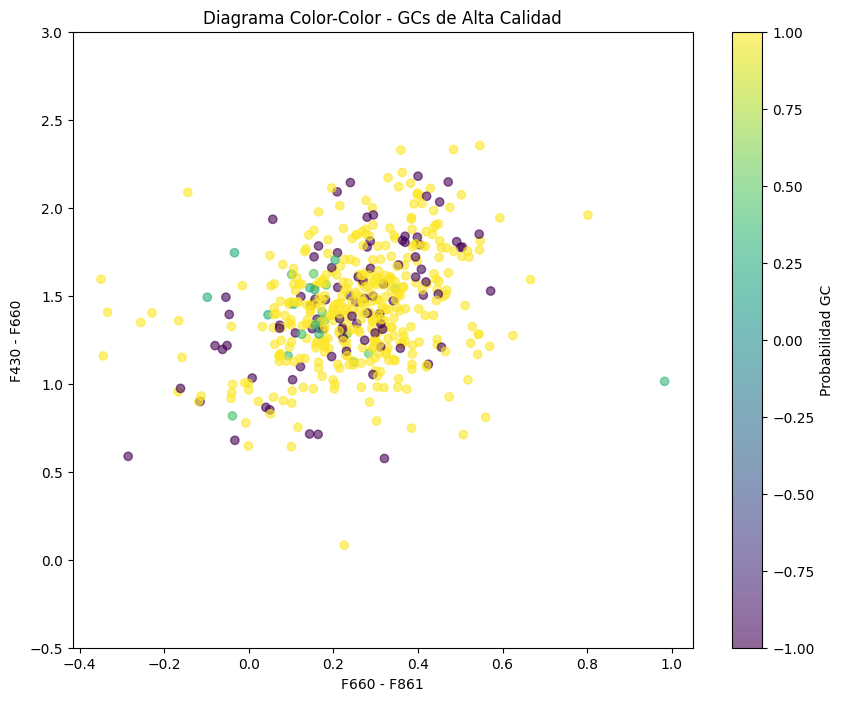

In [17]:
# Para empezar tu análisis científico inmediatamente:

# 1. Diagramas color-color
plt.figure(figsize=(10, 8))
plt.scatter(high_quality_df['MAG_F660_3'] - high_quality_df['MAG_F861_3'], 
           high_quality_df['MAG_F430_3'] - high_quality_df['MAG_F660_3'], 
           c=high_quality_df['Prob'] if 'Prob' in high_quality_df.columns else 'blue',
           alpha=0.6)
plt.xlabel('F660 - F861')
plt.ylabel('F430 - F660')
plt.ylim(-0.5, 3)

plt.colorbar(label='Probabilidad GC')
plt.title(f'Diagrama Color-Color - GCs de Alta Calidad')
plt.show()


In [18]:
import datetime
# Añadir metadatos de calidad
high_quality_df['QUALITY_CLEANING_DATE'] = datetime.datetime.now().strftime("%Y-%m-%d")
high_quality_df['QUALITY_CRITERIA'] = "High-Quality Strategy: error≠0.543, SNR>2.5, min_5_filters"
high_quality_df['SAMPLE_DESCRIPTION'] = "507 globular clusters in NGC 5128 - High quality photometry"

In [19]:
# Crear metadatos detallados como comentarios en un archivo separado o en el mismo CSV
metadata = {
    'creation_date': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'original_source': 'all_fields_gc_photometry_corrected_errors_v17.csv',
    'cleaning_strategy': 'High-Quality Strategy',
    'cleaning_criteria': [
        'Exclude all measurements with error = 0.543 (invalid measurements)',
        'Maximum error: 0.5 mag for all filters',
        'Minimum SNR: 2.5 for all filters', 
        'Minimum valid filters per source: 5',
        'Aperture used: 3 arcsec'
    ],
    'final_sample_size': len(high_quality_df),
    'retention_rate': f"{(len(high_quality_df)/len(df))*100:.1f}%",
    'filters_included': ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861'],
    'photometry_system': 'SPLESS (12 narrow bands) + Taylor+2017 (DECam ugriz)',
    'purpose': 'High-impact paper on globular clusters in Centaurus A',
    'contact': 'Luis A. Gutiérrez Soto - gsoto.angel@gmail.com'
}


In [20]:
# Guardar el catálogo principal
output_filename = "../anac_data/Results/gc_photometry_final_high_quality_preliminar_teste_v18.csv"
high_quality_df.to_csv(output_filename, index=False)

In [21]:
# Guardar un archivo de metadatos
metadata_filename = "../anac_data/Results/gc_photometry_metadata_507.txt"
with open(metadata_filename, 'w') as f:
    f.write("METADATA: Globular Cluster Photometry Catalog - NGC 5128\n")
    f.write("=" * 60 + "\n\n")
    for key, value in metadata.items():
        if isinstance(value, list):
            f.write(f"{key}:\n")
            for item in value:
                f.write(f"  - {item}\n")
        else:
            f.write(f"{key}: {value}\n")

In [22]:
# También guardar una versión "limpia" sin las columnas de apertura 2 para simplificar
columns_to_keep = [col for col in high_quality_df.columns if not col.endswith('_2')]
clean_version = high_quality_df[columns_to_keep]
clean_version.to_csv("../anac_data/Results/gc_photometry_final_high_quality_preliminar_aperture3_only_v18.csv", index=False)

print(f"""
✅ ARCHIVOS GUARDADOS EXITOSAMENTE:

📊 Catálogo principal: 
   {output_filename}
   - {len(high_quality_df)} fuentes de alta calidad
   - Todas las columnas originales + metadatos

📝 Metadatos:
   {metadata_filename}
   - Criterios de limpieza detallados
   - Información de procedencia

🎯 Versión simplificada:
   ../anac_data/Results/gc_photometry_final_507_aperture3_only.csv
   - Solo apertura 3 arcsec para análisis más simple

📋 RESUMEN FINAL:
   • Fuentes originales: {len(df)}
   • Fuentes de alta calidad: {len(high_quality_df)} 
   • Tasa de retención: {(len(high_quality_df)/len(df))*100:.1f}%
   • Filtros válidos por fuente: {high_quality_df[[f'MAGERR_{f}_3' for f in ['F378','F395','F410','F430','F515','F660','F861']]].notna().sum(axis=1).mean():.1f}
   • Criterio clave: EXCLUSIÓN COMPLETA de errores 0.543 (mediciones inválidas)

🚀 ¡Listo para análisis científico y publicación!
""")



✅ ARCHIVOS GUARDADOS EXITOSAMENTE:

📊 Catálogo principal: 
   ../anac_data/Results/gc_photometry_final_high_quality_preliminar_teste_v18.csv
   - 507 fuentes de alta calidad
   - Todas las columnas originales + metadatos

📝 Metadatos:
   ../anac_data/Results/gc_photometry_metadata_507.txt
   - Criterios de limpieza detallados
   - Información de procedencia

🎯 Versión simplificada:
   ../anac_data/Results/gc_photometry_final_507_aperture3_only.csv
   - Solo apertura 3 arcsec para análisis más simple

📋 RESUMEN FINAL:
   • Fuentes originales: 3799
   • Fuentes de alta calidad: 507 
   • Tasa de retención: 13.3%
   • Filtros válidos por fuente: 5.9
   • Criterio clave: EXCLUSIÓN COMPLETA de errores 0.543 (mediciones inválidas)

🚀 ¡Listo para análisis científico y publicación!



In [23]:
# Verificación final de que no quedan errores 0.543
remaining_0543 = 0
for filter in ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']:
    err_col = f'MAGERR_{filter}_3'
    if err_col in high_quality_df.columns:
        n_remaining = (high_quality_df[err_col] == 0.543).sum()
        remaining_0543 += n_remaining

if remaining_0543 == 0:
    print("🎉 VERIFICACIÓN EXITOSA: 0 mediciones con error 0.543 en la muestra final")
else:
    print(f"⚠️  ADVERTENCIA: {remaining_0543} mediciones con error 0.543 aún presentes")

🎉 VERIFICACIÓN EXITOSA: 0 mediciones con error 0.543 en la muestra final


In [24]:
# Estadísticas rápidas por filtro
print("\n📈 ESTADÍSTICAS POR FILTRO (apertura 3):")
for filter in ['F378', 'F395', 'F410', 'F430', 'F515', 'F660', 'F861']:
    err_col = f'MAGERR_{filter}_3'
    if err_col in high_quality_df.columns:
        n_valid = high_quality_df[err_col].notna().sum()
        avg_error = high_quality_df[err_col].mean()
        print(f"   {filter}: {n_valid} fuentes, error promedio: {avg_error:.3f} mag")


📈 ESTADÍSTICAS POR FILTRO (apertura 3):
   F378: 300 fuentes, error promedio: 0.288 mag
   F395: 233 fuentes, error promedio: 0.308 mag
   F410: 459 fuentes, error promedio: 0.250 mag
   F430: 488 fuentes, error promedio: 0.232 mag
   F515: 507 fuentes, error promedio: 0.127 mag
   F660: 507 fuentes, error promedio: 0.042 mag
   F861: 507 fuentes, error promedio: 0.078 mag
